## Double Speaker
Frequency - $5,000 Hz \ $ and $\ 7,000 Hz \ $.

Speeds - $1, 3, 5$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astrolab import timing as tim

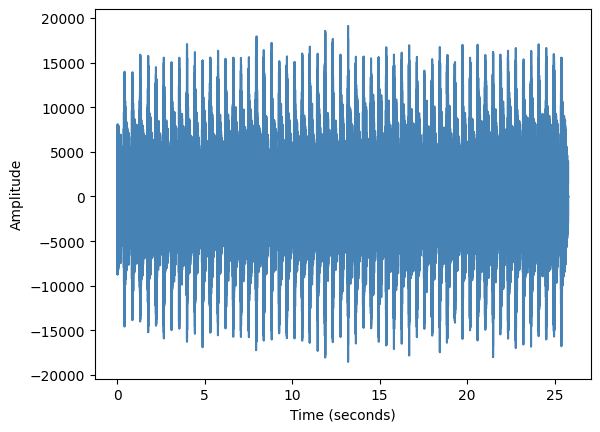

In [94]:
sr1, times1, sig1 = tim.load_signal(filename="./Double speaker speed 3 freq (2.5k, 8.5k).wav", print_log=True,clip=[5,45])

np.float64(2497.2705736945104)

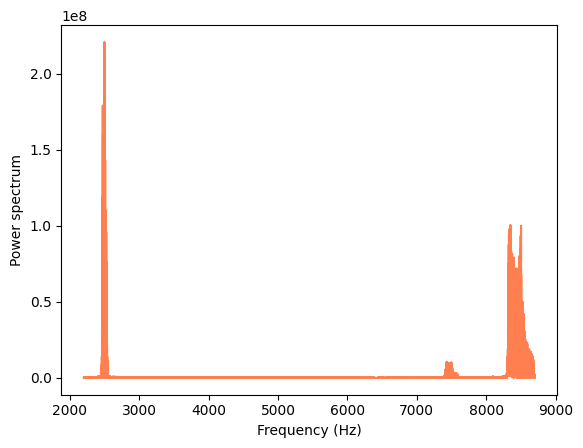

In [67]:
tim.power_spectrum(sig1, samplerate=sr1, print_log=True, lowx=2200, highx=8700)

The dominant frequencies for speaker 1 is 2524.8 and speaker 2 is 8342.400000000001


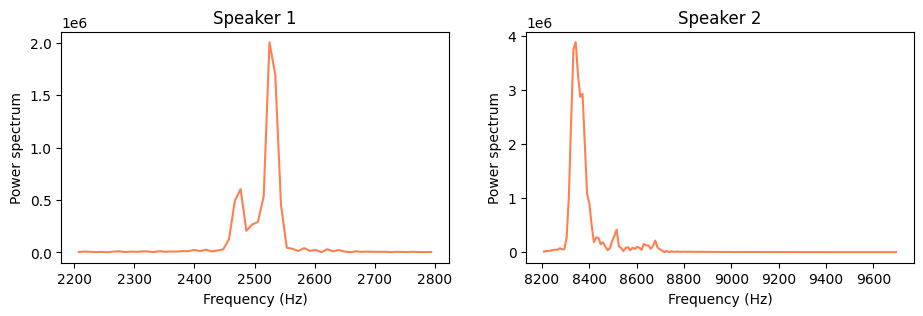

In [68]:
# Create a single chunk of 5000 data points, and plot its power spectrum

one_chunk1 = sig1[10000:15000]  # A single chunk

fig1, axes1 = plt.subplots(nrows=1, ncols=2, figsize=(11,3)) # Create a blank canvas for both plots

# For first speaker (5000 Hz)
axes1[0].set_title("Speaker 1")
speaker1_dom1 = tim.power_spectrum(one_chunk1, samplerate=sr1, print_log=True, lowx=2200, highx=2800, fig=fig1, ax=axes1[0])

# For the second speaker (7000 Hz)
axes1[1].set_title("Speaker 2")
speaker2_dom1 = tim.power_spectrum(one_chunk1, samplerate=sr1, print_log=True, lowx=8200, highx=9700, fig=fig1, ax=axes1[1])

print(f"The dominant frequencies for speaker 1 is {speaker1_dom1} and speaker 2 is {speaker2_dom1}")

In [69]:
avg_t1,chunks1 = tim.chunk_signal(times1, sig1, size=3335)          # Chunk the signal

n_chunks1 = len(chunks1)                               # Number of chunks

print("Total number of time-points is:", len(avg_t1)) # Print out the total number of time-steps and chunks
print("The number of chunks is:", n_chunks1)          # which should both be the same!

Total number of time-points is: 9682
The number of chunks is: 9682


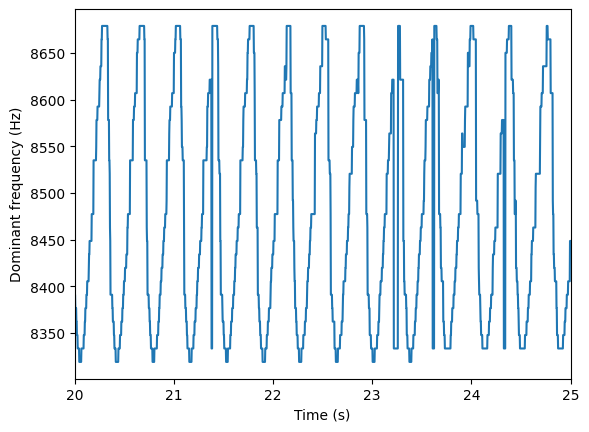

In [70]:
dominant_freqs1 = np.zeros(n_chunks1)   # Define an empty array to hold the dominant frequencies

for c1 in range(n_chunks1):             # Loop over all chunks
    # Store the dominant frequency of each chunk
    dominant_freqs1[c1] = tim.power_spectrum(chunk=chunks1[c1], samplerate=sr1, print_log = False, lowx=3500, highx=9500)

plt.plot(avg_t1, dominant_freqs1)       # Plot the dominant frequency of each chunk as a function of the chunk's "time"
plt.xlabel("Time (s)")                # Set the x-label
plt.ylabel("Dominant frequency (Hz)") # Set the y-label
plt.xlim(20,25)                         # Limit the x-range of the plot, to make it easier to read
plt.show()

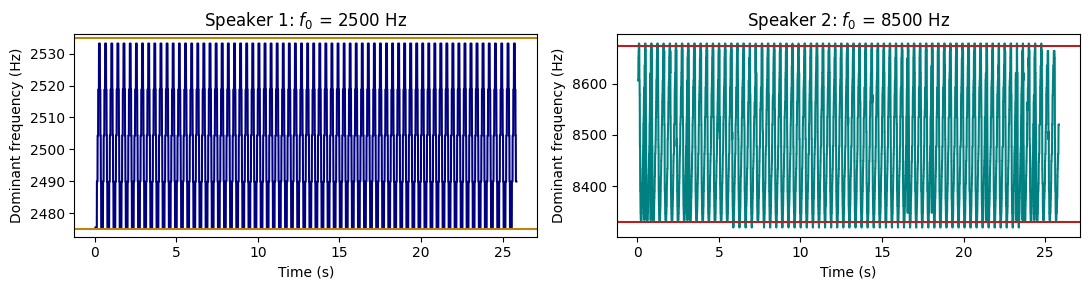

In [95]:
speaker1_f01 = 2500
speaker2_f01 = 8500

speaker1_dominant_freqs1 = np.zeros(n_chunks1)   # Define an empty array to hold the dominant frequencies for speaker 1
speaker2_dominant_freqs1 = np.zeros(n_chunks1)   # Define an empty array to hold the dominant frequencies for speaker 2

for c2 in range(n_chunks1):             # Loop over all chunks
    # Store the dominant frequency of each chunk for each speaker.
    # Note that the lowx and highx variables are different in each case, centred around the f0 for each speaker
    speaker1_dominant_freqs1[c2] = tim.power_spectrum(chunk=chunks1[c2], samplerate=sr1, print_log = False, lowx=2450, highx=2550)
    speaker2_dominant_freqs1[c2] = tim.power_spectrum(chunk=chunks1[c2], samplerate=sr1, print_log = False, lowx=8300, highx=8800)


fig2, axes2 = plt.subplots(nrows=1, ncols=2, figsize=(11,3))  # Create a blank canvas to plot our graphs

axes2[0].set_title(rf"Speaker 1: $f_0$ = {speaker1_f01} Hz")
axes2[0].plot(avg_t1, speaker1_dominant_freqs1, color='navy')  # Plot the dominant frequency of each chunk
axes2[0].set_xlabel("Time (s)")                              # Set the x-label
axes2[0].set_ylabel("Dominant frequency (Hz)")               # Set the y-label

axes2[1].set_title(rf"Speaker 2: $f_0$ = {speaker2_f01} Hz")
axes2[1].plot(avg_t1, speaker2_dominant_freqs1, color='teal')  # Plot the dominant frequency of each chunk
axes2[1].set_xlabel("Time (s)")                              # Set the x-label
axes2[1].set_ylabel("Dominant frequency (Hz)")               # Set the y-label

speaker1_fmax1 = 2535 #5063 # These values are found
speaker1_fmin1 = 2475 # through trial and error
speaker2_fmax1 = 8675
speaker2_fmin1 = 8330

axes2[0].axhline(speaker1_fmin1, color='darkgoldenrod')        # Plot horizontal lines for each guess
axes2[0].axhline(speaker1_fmax1, color='darkgoldenrod')        # The above values are adjusted so that the
                                                             # lines align with the maxima of each signal
axes2[1].axhline(speaker2_fmin1, color='firebrick')
axes2[1].axhline(speaker2_fmax1, color='firebrick')

plt.tight_layout()

In [93]:
distance_ratio1 = (speaker1_fmax1 - speaker1_fmin1)/(speaker2_fmax1 - speaker2_fmin1) * (speaker2_f01/speaker1_f01)

print("The distance ratio of speaker 1 and speaker 2 is", distance_ratio1)
print(speaker1_fmax1 - speaker1_fmin1)
print(speaker2_fmax1 - speaker2_fmin1)

The distance ratio of speaker 1 and speaker 2 is 0.5964912280701754
60
342
